<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [15]</a>'.</span>

In [1]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"


In [2]:
# Parameters
MAX_EPOCHS = 2000
N_SAMPLES = 1
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "/Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/FM_metrics_train.csv"


In [3]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


## 🛠️ Setup & Imports

In [4]:
!nvidia-smi

Sun Aug  9 14:49:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000000:E3:00.0 Off |                    0 |
| N/A   81C    P0            259W /  400W |   64329MiB /  95830MiB |    100%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

In [6]:
import math
import os
import zipfile
import glob
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import xarray as xr
import pandas as pd
import torch
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torchinfo import summary

import sys
sys.path.append('../..')    # → consistency/  (pour flowmatching_models_FM)
sys.path.append('../../..')  # → 4dvarnet-starter-devs/  (pour src)

from flowmatching_models_FM import (
    UNetFM, UNetFMConfig,
    LitFlowMatchingModel, LitFMConfig,
    LogScaleModel,
    heun_sample, euler_sample,
    neglogpdf, neglogcdf,
    sample_uniform_time, masked_average,
)

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("⚠️  properscoring non installé — CRPS désactivé. Installer avec: pip install properscoring")

## 🧠 Implementation

### DataModule — SPDE Diffusion Dataset

In [7]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "../../../data/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset>
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * lat        (lat) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * time       (time) int64 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 ...
    y          (time, lat, lon) float32 ...
    OI         (time, lat, lon) float64 ...
    H11        (lat, lon) float32 ...
    H22        (lat, lon) float32 ...
    H12        (lat, lon) float32 ...
    Time       (time) int64 ...
    longitude  (lon) int64 ...
    latitude   (lat) int64 ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('lat', 'lon')  shape=(128, 128)  dtype=float32
  H22

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes — input (y): (5, 128, 128), tgt (x): (5, 128, 128)


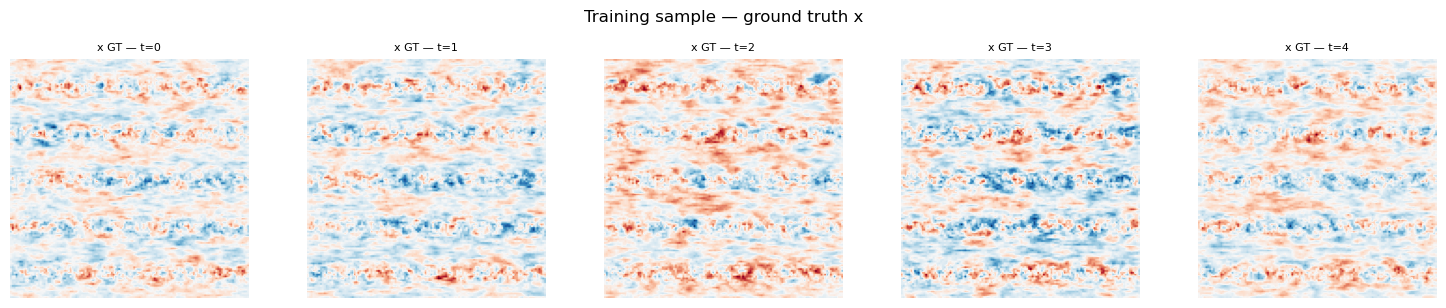

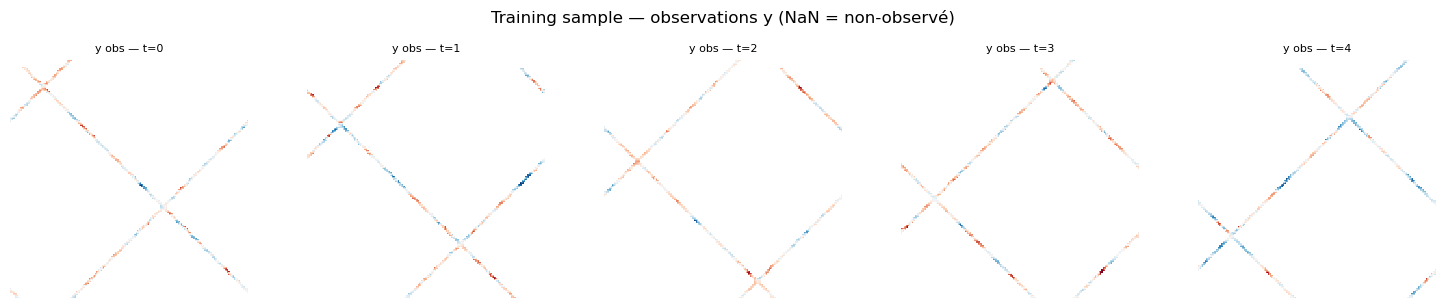

In [8]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = datamodule.window_size
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes — input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x GT — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — ground truth x", y=1.01)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y obs — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — observations y (NaN = non-observé)", y=1.01)
plt.tight_layout(); plt.show()

### UNetFM — Velocity-prediction network

The network takes as input the concatenation `(x_noisy, y_filled, mask_obs)` → `3×C` input channels,
and outputs a velocity field of `C` channels.

A reflection padding to the nearest multiple of 8 is applied at input and removed at output.
The noise level `σ` is encoded as a sinusoidal embedding injected into each UNetBlock via AdaGN.


In [9]:
C = datamodule.window_size
cfg = UNetFMConfig(channels=C)
net = UNetFM(cfg)

summary(
    net,
    input_size=(
        (1, C, 100, 100),   # x_t  — noisy interpolant
        (1, C, 100, 100),   # y    — observations (NaN tolerated)
        (1,),               # t    — pseudo-time scalar
    ),
)

Layer (type:depth-idx)                        Output Shape              Param #
UNetFM                                        [1, 5, 100, 100]          --
├─Conv2d: 1-1                                 [1, 64, 104, 104]         8,704
├─TimeEmbedding: 1-2                          [1, 128, 1, 1]            64
│    └─Sequential: 2-1                        [1, 128, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
│    │    └─Rearrange: 3-4                    [1, 128, 1, 1]            --
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 64, 104, 104]         --
│    │    └─Sequential: 3-5                   [1, 64, 104, 104]         37,056
│    │    └─Sequential: 3-6                   [1, 64, 1, 1]             8,256
│ 

### LightningModule — LitFlowMatchingModel

Uses the linear interpolant of Flow Matching: $x_t = (1-t)\,x_0 + t\,x_1$, $v^* = x_1 - x_0$.

The training step:
1. Sample $t \sim \mathcal{U}(0,1)$
2. Build $x_t = (1-t)\,\epsilon + t\,x_0$ where $\epsilon \sim \mathcal{N}(0, I)$
3. Train the network to predict the velocity $v^* = x_0 - \epsilon$


In [10]:
# LitFlowMatchingModel is fully self-contained in flowmatching_models_FM.py.
# Inspect its docstring:
help(LitFlowMatchingModel)

Help on class LitFlowMatchingModel in module flowmatching_models_FM:

class LitFlowMatchingModel(pytorch_lightning.core.module.LightningModule)
 |  LitFlowMatchingModel(network: 'UNetFM', config: 'LitFMConfig', n_log_scale_embedding: 'int' = 128) -> 'None'
 |  
 |  Flow Matching Lightning module for the SPDE dataset.
 |  
 |  Parameters
 |  ----------
 |  network     : ``UNetFM`` (student / live model)
 |  config      : ``LitFMConfig``
 |  n_log_scale_embedding : embedding dim for the ``LogScaleModel``
 |  
 |  Method resolution order:
 |      LitFlowMatchingModel
 |      pytorch_lightning.core.module.LightningModule
 |      lightning_fabric.utilities.device_dtype_mixin._DeviceDtypeModuleMixin
 |      pytorch_lightning.core.mixins.hparams_mixin.HyperparametersMixin
 |      pytorch_lightning.core.hooks.ModelHooks
 |      pytorch_lightning.core.hooks.DataHooks
 |      pytorch_lightning.core.hooks.CheckpointHooks
 |      torch.nn.modules.module.Module
 |      builtins.object
 |  
 |  Meth

## 🚀 Training

In [11]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        import zipfile
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last) and is_valid_checkpoint(last):
        print(f"✅ Valid checkpoint: {last}")
        return last
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt")) if "last" not in p],
        key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", ""))
        if "train_loss=" in p else float("inf"),
    )
    for p in all_ckpts:
        if is_valid_checkpoint(p):
            print(f"✅ Valid checkpoint: {p}")
            return p
    print("❌ No valid checkpoint found. Starting from scratch.")
    return None

# ── Paths ──────────────────────────────────────────────────────────────────
C = datamodule.window_size

LOG_DIR     = "logs_FM_spde"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")

# RESET_TRAINING set by the parameters cell above
if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    resume_ckpt = None
    print("RESET_TRAINING=True -- starting from scratch")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

# ── Model ──────────────────────────────────────────────────────────────────
network   = UNetFM(UNetFMConfig(channels=C))
lit_fm    = LitFlowMatchingModel(
    network=network,
    config=LitFMConfig(lr_scheduler_iters=1000, eval_n_steps=20),
)

# ── Trainer ────────────────────────────────────────────────────────────────
trainer = Trainer(enable_progress_bar=False, 
    accelerator="gpu",
    max_epochs=MAX_EPOCHS,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="train_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
trainer.fit(lit_fm, datamodule, ckpt_path=resume_ckpt)

# ── Save EMA model ─────────────────────────────────────────────────────────
ema_net = lit_fm.ema_model.module
ema_net.save_pretrained(MODEL_PATH)
print(f"✅ EMA model saved to: {MODEL_PATH}")

✅ Valid checkpoint: logs_FM_spde/checkpoints/last.ckpt


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /Odyssey/private/m19beauc/conda_envs/4dvarnet-starte ...
  rank_zero_warn(
Using 16bit Automatic Mixed Precision (AMP)


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


...

[Epoch 1998]  Val RMSE (20 Heun steps, EMA) = 0.9093


[progress] epoch 2000/2000 | train_loss=0.5712 | train_loss_epoch=0.5712 | train_loss_step=0.6325 | val_rmse_ema=0.9093


[Epoch 1999]  Val RMSE (20 Heun steps, EMA) = 0.9119


`Trainer.fit` stopped: `max_epochs=2000` reached.


✅ EMA model saved to: logs_FM_spde/best_model


## 🎲 Sampling & Evaluation

In [12]:

# ── Load EMA model for inference ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32

# Must match MODEL_PATH used in the training cell
MODEL_PATH = os.path.join("logs_FM_spde", "best_model")

ema_unet = UNetFM.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"EMA UNetFM loaded from {MODEL_PATH}")
print(f"  Device : {next(ema_unet.parameters()).device}")
print(f"  Params : {sum(p.numel() for p in ema_unet.parameters()):,}")


EMA UNetFM loaded from logs_FM_spde/best_model
  Device : cuda:0
  Params : 32,269,829


### Test Batch


In [13]:
# ── Test batch ────────────────────────────────────────────────────────────────
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

x_gt  = batch.tgt.to(device=device, dtype=dtype)    # (B, C, H, W) ground truth
y_obs = batch.input.to(device=device, dtype=dtype)  # (B, C, H, W) sparse obs (NaN=missing)

B, C, H, W = x_gt.shape
print(f"Test batch  x_gt:{tuple(x_gt.shape)}  y_obs:{tuple(y_obs.shape)}")

start_t = datamodule.test_ds.indices[0]
x_oi_np = datamodule.oi[start_t : start_t + C].astype(np.float32)  # (C, H, W)
m_norm, s_norm = datamodule.norm_stats()


[rank: 0] Global seed set to 42


Test batch  x_gt:(1, 5, 128, 128)  y_obs:(1, 5, 128, 128)


### Ensemble Generation (N_SAMPLES members)


In [14]:

# N_SAMPLES set by the parameters cell above
N_STEPS   = 20   # Heun ODE steps

samples = []  # list of (B, C, H, W) tensors

with torch.no_grad():
    for s in range(N_SAMPLES):
        noise = torch.randn_like(x_gt)                         # fresh noise per member
        x_pred, _ = heun_sample(ema_unet, noise, y_obs, n_steps=N_STEPS)
        samples.append(x_pred.cpu())
        if (s + 1) % 10 == 0:
            print(f"  member {s+1}/{N_SAMPLES} done")

samples = torch.stack(samples, dim=0)   # (N_SAMPLES, B, C, H, W)
print(f"Ensemble tensor: {tuple(samples.shape)}")

ens_mean = samples.mean(0)              # (B, C, H, W)
ens_std  = samples.std(0)              # (B, C, H, W)
print(f"Ensemble mean range: [{ens_mean.min():.3f}, {ens_mean.max():.3f}]")
print(f"Ensemble std  range: [{ens_std.min():.3f}, {ens_std.max():.3f}]")

# Squeeze batch dim for downstream metrics (use first batch item)
_b = 0
ens_mean_1 = ens_mean[_b]   # (C, H, W) normalized
ens_std_1  = ens_std[_b]    # (C, H, W) normalized
ensemble_1 = samples[:, _b] # (N, C, H, W) normalized


Ensemble tensor: (1, 1, 5, 128, 128)
Ensemble mean range: [-5.223, 4.762]
Ensemble std  range: [nan, nan]


/tmp/ipykernel_2110587/120397973.py:18: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1879.)
  ens_std  = samples.std(0)              # (B, C, H, W)


### Publication Figures — comparison & uncertainty


<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [15]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'FM_spde'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

C = datamodule.window_size

obs_phys  = batch.input[_b].float().cpu().numpy() * s_norm + m_norm   # (C,H,W) NaN ok
gt_phys   = batch.tgt[_b].float().cpu().numpy()   * s_norm + m_norm   # (C,H,W)
oi_phys   = x_oi_np                                                    # (C,H,W) physical
mean_phys = ens_mean_1.float().cpu().numpy() * s_norm + m_norm         # (C,H,W)
std_phys  = ens_std_1.float().cpu().numpy()  * s_norm                  # (C,H,W)
mbr0_phys = ensemble_1[0].float().cpu().numpy() * s_norm + m_norm      # (C,H,W)
mbr1_phys = ensemble_1[1].float().cpu().numpy() * s_norm + m_norm      # (C,H,W)

vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f
vmax_s = float(np.nanpercentile(std_phys, 99))

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')
cmap_s = plt.cm.Reds.copy();   cmap_s.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C,
                  left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

figures = [
    (obs_phys,  f'{FIG_TAG}_obs',      vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',       vmin_f, vmax_f, cmap_f),
    (oi_phys,   f'{FIG_TAG}_oi',       vmin_f, vmax_f, cmap_f),
    (mean_phys, f'{FIG_TAG}_fm_mean',  vmin_f, vmax_f, cmap_f),
    (std_phys,  f'{FIG_TAG}_fm_spread',0.0,    vmax_s, cmap_s),
    (mbr0_phys, f'{FIG_TAG}_member0',  vmin_f, vmax_f, cmap_f),
    (mbr1_phys, f'{FIG_TAG}_member1',  vmin_f, vmax_f, cmap_f),
]

for data, fname, vmin, vmax, cmap in figures:
    _save_strip(data, fname, vmin, vmax, cmap)


IndexError: index 1 is out of bounds for dimension 0 with size 1

### ODE Transport Process — Heun trajectory


In [ ]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

T_CH   = datamodule.window_size // 2   # displayed time channel (t=2)
N_SHOW = 10                             # max frames

N_VIZ_STEPS = 20
torch.manual_seed(42)
noise_traj = torch.randn(1, C, H, W, device=device, dtype=dtype)
y_traj     = y_obs[0:1]

with torch.no_grad():
    _, trajectory = heun_sample(ema_unet, noise_traj, y_traj, n_steps=N_VIZ_STEPS)

# trajectory: list of (1, C, H, W) tensors, length = N_VIZ_STEPS + 1
transport_n = torch.stack(trajectory, dim=0)[:, 0, T_CH, :, :].float().cpu().numpy()
transport_p = transport_n * s_norm + m_norm

nfr = transport_p.shape[0]
stride = max(1, nfr // N_SHOW)
idx_show = list(range(0, nfr, stride))
if (nfr - 1) not in idx_show:
    idx_show.append(nfr - 1)
frames = transport_p[idx_show]
nf = len(frames)

# Layout (all in inches, from bottom to top)
FW, FH   = 2.4, 2.4   # frame width / height
ARR_H    = 0.28        # arrow zone
GAP_1    = 0.14        # gap: arrow -> colorbar
CB_H     = 0.26        # colorbar height
GAP_2    = 0.16        # gap: colorbar -> images

fig_w = nf * FW
fig_h = ARR_H + GAP_1 + CB_H + GAP_2 + FH

# Figure-fraction positions (y = 0 at bottom)
arr_y_f   = (ARR_H / 2) / fig_h
cb_bot_f  = (ARR_H + GAP_1) / fig_h
cb_h_f    = CB_H / fig_h
img_bot_f = (ARR_H + GAP_1 + CB_H + GAP_2) / fig_h

fig = plt.figure(figsize=(fig_w, fig_h))

gs = GridSpec(1, nf, left=0.01, right=0.99,
              top=0.99, bottom=img_bot_f,
              hspace=0, wspace=0.02)

vmax_t = float(np.nanpercentile(np.abs(transport_p), 99))
cmap_t = plt.cm.RdBu_r
for i in range(nf):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(frames[i], origin='lower', cmap=cmap_t,
              vmin=-vmax_t, vmax=vmax_t, interpolation='nearest')
    ax.axis('off')

# Horizontal colorbar
cb_ax = fig.add_axes([0.15, cb_bot_f, 0.70, cb_h_f])
sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(-vmax_t, vmax_t))
sm.set_array([])
cb = fig.colorbar(sm, cax=cb_ax, orientation='horizontal')
cb.set_label('GP field (physical units)', fontsize=24, fontweight='bold')
cb.ax.tick_params(labelsize=20)

# Temporal arrow
fig.add_artist(mpatches.FancyArrowPatch(
    (0.04, 1+arr_y_f), (0.96, 1+arr_y_f),
    transform=fig.transFigure, arrowstyle='-|>',
    color='black', mutation_scale=32, linewidth=1.5,
))
fig.text(0.02, 1+arr_y_f, 'noise', va='bottom', ha='left',  fontsize=24, color='steelblue')
fig.text(0.98, 1+arr_y_f, 'clean', va='bottom', ha='right', fontsize=24, color='tomato')
fig.text(0.50, 1+arr_y_f, 'ODE time (Heun)', va='bottom', ha='center', fontsize=24)

fpath = os.path.join(FIG_DIR, f'{FIG_TAG}_transport.png')
fig.savefig(fpath, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath}')
plt.show()


## 📊 Metrics — Flow Matching vs OI

Evaluation at the **centre of the assimilation window** (`t=T_EVAL`, `C=5`).

| Metric | Description |
|---|---|
| **Score ↑** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE ↓** | Root Mean Square Error vs GT |
| **σ_pred** | Standard deviation of the ensemble mean |
| **CRPS ↓** | Continuous Ranked Probability Score at **observed** pixels |
| **λx ↓** | Resolved scale (px): wavelength where spectral score = 0.5 |


In [ ]:
import sys
sys.path.append('../..')   # -> consistency/
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale
import pandas as pd

try:
    from properscoring import crps_ensemble as crps_ens_fn
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("⚠️  properscoring not installed — CRPS disabled.")

DX_PX  = 1.0                           # 1 pixel = 1 km (assumption)

# ── Full test-set evaluation ─────────────────────────────────────────────
# Loops over EVERY batch of datamodule.test_dataloader() (not just the first
# one used for the illustrative figures above) and EVERY timestep of the
# assimilation window (not just T_EVAL=window_size//2), and compares against
# the matching OI baseline slice for every (sample, timestep) pair. This is
# the expensive part (N_SAMPLES x n_test_batches Heun integrations) --
# N_SAMPLES was reduced from 50 to 20 in methods.yaml specifically to keep a
# full-test-set pass affordable. GP is a synthetic continuous field, so
# unlike SIC there is no MIZ-style domain restriction -- metrics are
# aggregated over the whole spatial domain.
_all_fm = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'crps': [], 'lambda_x': []}
_all_oi = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'lambda_x': []}
_n_pairs = 0
_sample_counter = 0

seed_everything(42)
for _tb in datamodule.test_dataloader():
    _x_gt_b = _tb.tgt.to(device=device, dtype=dtype)      # (B, C, H, W)
    _y_b    = _tb.input.to(device=device, dtype=dtype)     # (B, C, H, W)
    _Bb, _Cb, _Hb, _Wb = _x_gt_b.shape
    _valid_b   = ~torch.isnan(_x_gt_b)
    _obsmask_b = ~torch.isnan(_y_b)

    with torch.no_grad():
        _members = []
        for _ in range(N_SAMPLES):
            _noise = torch.randn_like(_x_gt_b)
            _x_pred, _ = heun_sample(ema_unet, _noise, _y_b, n_steps=N_STEPS)
            _members.append(_x_pred.cpu())
    _ens_b = torch.stack(_members, dim=0)         # (N, B, C, H, W) normalised
    _ens_mean_b = _ens_b.mean(0)                   # (B, C, H, W)

    for _bi in range(_Bb):
        _start_t = datamodule.test_ds.indices[_sample_counter]
        _sample_counter += 1
        _oi_traj = datamodule.oi[_start_t : _start_t + _Cb].astype(np.float32)   # (C, H, W)

        for _t in range(_Cb):
            _valid_t = _valid_b[_bi, _t].cpu().numpy()
            if _valid_t.sum() < 10:
                continue
            _gt_p   = _x_gt_b[_bi, _t].float().cpu().numpy() * s_norm + m_norm
            _mean_p = _ens_mean_b[_bi, _t].float().numpy()    * s_norm + m_norm
            _ens_p  = _ens_b[:, _bi, _t].float().numpy()      * s_norm + m_norm
            _oi_p   = _oi_traj[_t]

            _gt_v, _pred_v = _gt_p[_valid_t], _mean_p[_valid_t]
            _sigma = float(np.std(_gt_v))
            if _sigma <= 0:
                continue
            _rmse  = float(np.sqrt(np.mean((_pred_v - _gt_v) ** 2)))
            _score = 1.0 - _rmse / _sigma
            _sigma_pred = float(np.std(_pred_v))

            _gt_f   = np.nan_to_num(_gt_p,   nan=0.0)
            _pred_f = np.nan_to_num(_mean_p, nan=0.0)
            _wl, _, _, _spec = psd_spectral_score(_pred_f, _gt_f, dx=DX_PX)
            _lam = resolved_scale(_wl, _spec, threshold=0.5)

            _crps_val = np.nan
            if HAS_PROPERSCORING:
                _obs_t  = _obsmask_b[_bi, _t].cpu().numpy()
                _obs_ij = np.argwhere(_valid_t & _obs_t)
                if len(_obs_ij) > 0:
                    _stride = max(1, len(_obs_ij) // 50)   # subsample -- CRPS is O(n) Python loop
                    _crps_val = float(np.mean([
                        crps_ens_fn(float(_gt_p[i, j]), _ens_p[:, i, j])
                        for i, j in _obs_ij[::_stride]
                    ]))

            _all_fm['score'].append(_score)
            _all_fm['rmse'].append(_rmse)
            _all_fm['sigma_gt'].append(_sigma)
            _all_fm['sigma_pred'].append(_sigma_pred)
            _all_fm['crps'].append(_crps_val)
            _all_fm['lambda_x'].append(_lam)

            # OI baseline, same (sample, timestep) pair
            _oi_v = _oi_p[_valid_t]
            _rmse_oi  = float(np.sqrt(np.mean((_oi_v - _gt_v) ** 2)))
            _score_oi = 1.0 - _rmse_oi / _sigma
            _sigma_oi_pred = float(np.std(_oi_v))
            _oi_f = np.nan_to_num(_oi_p, nan=0.0)
            _wl_oi, _, _, _spec_oi = psd_spectral_score(_oi_f, _gt_f, dx=DX_PX)
            _lam_oi = resolved_scale(_wl_oi, _spec_oi, threshold=0.5)
            _all_oi['score'].append(_score_oi)
            _all_oi['rmse'].append(_rmse_oi)
            _all_oi['sigma_gt'].append(_sigma)
            _all_oi['sigma_pred'].append(_sigma_oi_pred)
            _all_oi['lambda_x'].append(_lam_oi)

            _n_pairs += 1

print(f"Evaluated {_n_pairs} (test sample, timestep) pairs across the full test set")

def _agg(vals):
    a = np.asarray(vals, dtype=float)
    a = a[~np.isnan(a)]
    return (float(np.mean(a)), float(np.std(a))) if len(a) else (np.nan, np.nan)

def _row(all_dict, label, has_crps=True):
    score_m, score_s = _agg(all_dict['score'])
    rmse_m, rmse_s   = _agg(all_dict['rmse'])
    sgt_m, sgt_s     = _agg(all_dict['sigma_gt'])
    spr_m, spr_s     = _agg(all_dict['sigma_pred'])
    lam_m, lam_s     = _agg(all_dict['lambda_x'])
    row = {
        'Method'   : label,
        'Score ↑'  : f'{score_m:.3f} ± {score_s:.3f}',
        'RMSE ↓'   : f'{rmse_m:.4f} ± {rmse_s:.4f}',
        'σ_GT'     : f'{sgt_m:.4f} ± {sgt_s:.4f}',
        'σ_pred'   : f'{spr_m:.4f} ± {spr_s:.4f}',
        'λx [px]'  : f'{lam_m:.1f} ± {lam_s:.1f}' if not np.isnan(lam_m) else '?',
    }
    if has_crps:
        crps_m, crps_s = _agg(all_dict['crps'])
        row['CRPS ↓'] = f'{crps_m:.4f} ± {crps_s:.4f}' if not np.isnan(crps_m) else '--'
    return row

row_fm = _row(_all_fm, 'FM (ens. mean, full test set)', has_crps=True)
row_oi = _row(_all_oi, 'OI baseline (full test set)',    has_crps=False)
row_oi['CRPS ↓'] = '--'

df_metrics = pd.DataFrame([row_fm, row_oi]).set_index('Method')
df_metrics = df_metrics[['Score ↑','RMSE ↓','σ_GT','σ_pred','CRPS ↓','λx [px]']]
print(f'\n## Metrics -- full test set (whole domain), n={_n_pairs} (sample,t) pairs\n')
display(df_metrics)

# ── Illustrative PSD plot (single example, T_EVAL=window_size//2 of the first
# test batch, same one used by the figures above) -- qualitative check only,
# NOT the quantitative table (that's df_metrics above, full test set now).
T_EVAL = datamodule.window_size // 2
gt_p_ex   = batch.tgt[_b, T_EVAL].float().cpu().numpy() * s_norm + m_norm
mean_p_ex = ens_mean_1[T_EVAL].float().cpu().numpy()    * s_norm + m_norm
oi_p_ex   = x_oi_np[T_EVAL]

wl_gt,  psd_gt_sig  = radial_psd_2d(gt_p_ex,   dx=DX_PX)
wl_fm2, psd_fm_sig  = radial_psd_2d(mean_p_ex, dx=DX_PX)
wl_oi2, psd_oi_sig  = radial_psd_2d(oi_p_ex,   dx=DX_PX)
wl_fm, _, _, spec_fm = psd_spectral_score(mean_p_ex, gt_p_ex, dx=DX_PX)
wl_oi, _, _, spec_oi = psd_spectral_score(oi_p_ex,   gt_p_ex, dx=DX_PX)
lambda_x_fm = resolved_scale(wl_fm, spec_fm)
lambda_x_oi = resolved_scale(wl_oi, spec_oi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for wl, psd, color, ls, lbl in [
    (wl_gt,  psd_gt_sig,  'black', '-',  'GT'),
    (wl_fm2, psd_fm_sig,  'C0',   '-',  'FM (ens. mean)'),
    (wl_oi2, psd_oi_sig,  'C1',   '--', 'OI baseline'),
]:
    v = np.isfinite(wl) & np.isfinite(psd) & (wl > 0) & (psd > 0)
    ax.loglog(1.0/wl[v], psd[v], color=color, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Spatial frequency  [cycles / pixel]')
ax.set_ylabel('PSD')
ax.set_title(f'Radial PSD (Hann, illustrative t={T_EVAL})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
lbl_fm = f'FM  (λx = {lambda_x_fm:.1f} px)' if not np.isnan(lambda_x_fm) else 'FM'
lbl_oi = f'OI  (λx = {lambda_x_oi:.1f} px)' if not np.isnan(lambda_x_oi) else 'OI'
for wl, spec, color, ls, lbl in [
    (wl_fm, spec_fm, 'C0', '-',  lbl_fm),
    (wl_oi, spec_oi, 'C1', '--', lbl_oi),
]:
    v = np.isfinite(wl) & np.isfinite(spec)
    ax.plot(wl[v], spec[v], color=color, ls=ls, lw=2, label=lbl)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_fm):
    ax.axvline(lambda_x_fm, color='C0', lw=1, ls=':')
if not np.isnan(lambda_x_oi):
    ax.axvline(lambda_x_oi, color='C1', lw=1, ls=':')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD  = 1 − PSD(err) / PSD(GT) (illustrative)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')
